In [ ]:
import os 
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd 
import numpy as np
from sklearn import tree
import graphviz
from src.model_utils import load_model, train_model, save_model, tune_model
from src.preprocessor_utils import convert_time_to_hour
from src.eval_metric import f1_benchmark, AUPRC, evaluate_model
from src.plot import plot_confusion_matrix_percent,plot_prediction_distribution, find_optimal_threshold
import joblib

d:\anaconda\envs\tf_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = os.path.join(project_root,"data","train_goc.csv")
df = pd.read_csv(data_path)
test_path = os.path.join(project_root,"data",'test_goc.csv')
df_test = pd.read_csv(test_path)

x_t = df_test.drop('Class',axis = 1)
y_test = df_test['Class']

x = df.drop('Class', axis = 1)
y_train = df['Class']

preprocessor_path = os.path.join(project_root,"data","creditcard_preprocessor.pkl")
preprocessor = joblib.load(preprocessor_path)

x_train = preprocessor.transform(x)
x_test = preprocessor.transform(x_t)

In [3]:
nb_path = os.path.join(project_root,"configs","nb_opt_raw.json")
svm_path = os.path.join(project_root,'configs',"svm_opt_raw.json")

In [4]:
model_nb = tune_model(x_train,y_train,"nb","optuna",nb_path,cv = 5,n_iter =50)

d:\PYTHON\data_mining\fraud-detecion-project\src\model_utils.py:162: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return OptunaSearchCV(
[I 2025-12-09 06:11:05,596] A new study created in memory with name: no-name-94113c83-4fe0-4de1-ada9-684247c86fb9


--- Bắt đầu Tuning NB bằng OPTUNA ---


[I 2025-12-09 06:11:08,897] Trial 5 finished with value: 0.11097475116091464 and parameters: {'var_smoothing': 2.300546682926255e-06}. Best is trial 5 with value: 0.11097475116091464.
[I 2025-12-09 06:11:09,326] Trial 8 finished with value: 0.11097475116091464 and parameters: {'var_smoothing': 6.605087979080817e-10}. Best is trial 5 with value: 0.11097475116091464.
[I 2025-12-09 06:11:09,372] Trial 11 finished with value: 0.11097475116091464 and parameters: {'var_smoothing': 8.886826200440124e-10}. Best is trial 5 with value: 0.11097475116091464.
[I 2025-12-09 06:11:09,420] Trial 2 finished with value: 0.11097475116091464 and parameters: {'var_smoothing': 6.959854791728924e-06}. Best is trial 5 with value: 0.11097475116091464.
[I 2025-12-09 06:11:09,428] Trial 9 finished with value: 0.11097475116091464 and parameters: {'var_smoothing': 3.437141622188875e-07}. Best is trial 5 with value: 0.11097475116091464.
[I 2025-12-09 06:11:09,448] Trial 4 finished with value: 0.11097475116091464 an


=== Kết quả Tuning ===
Best Params: {'var_smoothing': 2.300546682926255e-06}
Best Score (f1): 0.1110


--- ĐÁNH GIÁ: NAIVE BAYES OPTUNA ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.81      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.89      0.55     56746
weighted avg       1.00      0.98      0.99     56746

ROC-AUC: 0.9463
PR-AUC (AUPRC): 0.0761 (Quan trọng cho Fraud)


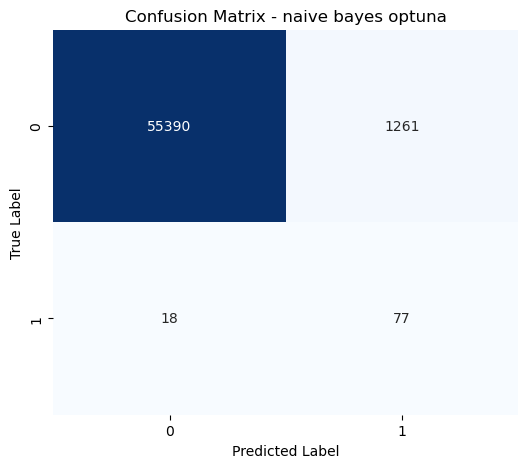

In [5]:
evaluate_model(model_nb[0],x_test,y_test,"naive bayes optuna")

với mô hình naive bayes có vẻ là không phù hợp với bộ dữ liệu này khá điểm khá thấp
điểm precision khá thấp nghĩa là với 1 lần thông báo là gian lận giao dịch thì chỉ có 6% là thật, có nghĩa là trong 100 lần báo gian lận thì chỉ có 6 giao dịch là chính xác gian lận

có thể nói là gần như mô hình này chỉ có giá trị thực hành để trãi nghiệm chứ không thể nào thật sự dự đoán với mô hình này.

In [7]:
path = os.path.join(project_root,'models','model_nb_opt_raw.pkl')
save_model(model_nb,path)

'Đã lưu model vào: d:\\PYTHON\\data_mining\\fraud-detecion-project\\models\\model_nb_opt_raw.pkl '